# NEO API - Data Discovery

I was curious about how scientists evaluate risk for objects that come close 
to Earth. How do they determine we are not in danger, even when asteroids pass 
relatively close? This notebook explores the NASA Near Earth Object (NEO) API 
from scratch, starting with the raw API response and working toward understanding 
what the data actually contains and what questions it can answer.

This is a discovery notebook, not a pipeline. The goal is to understand the 
data before deciding how to store and transform it.

---

## Table of contents

1. [Setup](#1-setup)

2. [Hit the API](#2-hit-the-api)

3. [Understand the structure](#3-understand-the-structure)

4. [Explore one asteroid](#4-explore-one-asteroid)

5. [Flatten to a dataframe](#5-flatten-to-a-dataframe)

6. [Fix types](#6-fix-types)

7. [Basic EDA](#7-basic-eda)

8. [Visualizations](#8-visualizations)

9. [Summary](#9-summary)

## 1. Setup <a id="1-setup"></a>

In [2]:
import requests
import json
import os
from dotenv import load_dotenv

load_dotenv('../.env')
API_KEY = os.getenv("NASA_API_KEY")
BASE_URL = "https://api.nasa.gov"

print("API key loaded:", API_KEY is not None)

API key loaded: True


## 2. Hit the API <a id="2-hit-the-api"></a>

Pull one week of data and look at the raw response first before doing anything else.

In [ ]:
# just hit the API and look at what comes back raw
response = requests.get(
    f"{BASE_URL}/neo/rest/v1/feed",
    params={
        "start_date": "2026-05-01",
        "end_date": "2026-05-07",
        "api_key": API_KEY
    }
)

print("Status:", response.status_code)
print(response.text[:2000])

## 3. Understand the structure <a id="3-understand-the-structure"></a>

The response is JSON. Parse it and read the structure level by level before 
touching the data.

In [ ]:
data = response.json()

# top level keys
print("Top level keys:", list(data.keys()))
print("Element count:", data["element_count"])
print("Dates returned:", list(data["near_earth_objects"].keys()))

dict_keys(['links', 'element_count', 'near_earth_objects'])


The response has three top level keys: `links`, `element_count`, and 
`near_earth_objects`. The near earth objects are organized as a dictionary 
indexed by date, each date maps to a list of asteroids that had a close 
approach that day.

In [33]:
# how many asteroids per date?
for date, asteroids in data["near_earth_objects"].items():
    print(f"{date} → {len(asteroids)} asteroids")

2026-05-02 → 2 asteroids
2026-05-01 → 7 asteroids
2026-05-07 → 3 asteroids
2026-05-06 → 3 asteroids
2026-05-05 → 3 asteroids
2026-05-04 → 8 asteroids
2026-05-03 → 3 asteroids


## 4. Explore one asteroid <a id="4-explore-one-asteroid"></a>

Pull out a single asteroid and see what fields we got.

In [34]:
first_date = list(data["near_earth_objects"].keys())[0]
first_asteroid = data["near_earth_objects"][first_date][0]

print(json.dumps(first_asteroid, indent=2))

{
  "links": {
    "self": "http://api.nasa.gov/neo/rest/v1/neo/3092253?api_key=eaNVHvsiuHrqumLzux7yAar4azfobC3nFVj0zM3j"
  },
  "id": "3092253",
  "neo_reference_id": "3092253",
  "name": "(2000 EM26)",
  "nasa_jpl_url": "https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=3092253",
  "absolute_magnitude_h": 22.51,
  "estimated_diameter": {
    "kilometers": {
      "estimated_diameter_min": 0.0836671502,
      "estimated_diameter_max": 0.1870854353
    },
    "meters": {
      "estimated_diameter_min": 83.6671501888,
      "estimated_diameter_max": 187.0854353059
    },
    "miles": {
      "estimated_diameter_min": 0.0519883408,
      "estimated_diameter_max": 0.116249464
    },
    "feet": {
      "estimated_diameter_min": 274.4985330255,
      "estimated_diameter_max": 613.7973795689
    }
  },
  "is_potentially_hazardous_asteroid": false,
  "close_approach_data": [
    {
      "close_approach_date": "2026-05-02",
      "close_approach_date_full": "2026-May-02 06:01",
      "ep

In [35]:
# what keys are available?
print("Top level:", list(first_asteroid.keys()))
print("\nDiameter units:", list(first_asteroid["estimated_diameter"].keys()))
print("\nClose approach keys:", list(first_asteroid["close_approach_data"][0].keys()))
print("\nVelocity units:", list(first_asteroid["close_approach_data"][0]["relative_velocity"].keys()))
print("\nMiss distance units:", list(first_asteroid["close_approach_data"][0]["miss_distance"].keys()))

Top level: ['links', 'id', 'neo_reference_id', 'name', 'nasa_jpl_url', 'absolute_magnitude_h', 'estimated_diameter', 'is_potentially_hazardous_asteroid', 'close_approach_data', 'is_sentry_object']

Diameter units: ['kilometers', 'meters', 'miles', 'feet']

Close approach keys: ['close_approach_date', 'close_approach_date_full', 'epoch_date_close_approach', 'relative_velocity', 'miss_distance', 'orbiting_body']

Velocity units: ['kilometers_per_second', 'kilometers_per_hour', 'miles_per_hour']

Miss distance units: ['astronomical', 'lunar', 'kilometers', 'miles']


**Fields NASA gives us per asteroid:**

| Field | Type | Notes |
|---|---|---|
| id, name, nasa_jpl_url | string | identity |
| absolute_magnitude_h | float | intrinsic brightness, relates to size |
| estimated_diameter | nested dict | km, meters, miles, feet |
| is_potentially_hazardous_asteroid | bool | size + orbit based |
| is_sentry_object | bool | NASA impact watch list |
| close_approach_date | string | needs datetime conversion |
| close_approach_date_full | string | date + exact time |
| relative_velocity | nested dict | km/s, km/h, mph - all strings |
| miss_distance | nested dict | AU, lunar, km, miles - all strings |

> Note: velocity and miss distance values are strings even though they look 
> like numbers. NASA wraps them in quotes. Must cast to float in the pipeline.

In [45]:
# size range across all 29 objects
all_asteroids = []
for date, asteroids in data["near_earth_objects"].items():
    for asteroid in asteroids:
        all_asteroids.append(asteroid)

print(f"Total asteroids: {len(all_asteroids)}\n")

for a in all_asteroids:
    name = a["name"]
    d_min = a["estimated_diameter"]["kilometers"]["estimated_diameter_min"]
    d_max = a["estimated_diameter"]["kilometers"]["estimated_diameter_max"]
    hazardous = a["is_potentially_hazardous_asteroid"]
    sentry = a["is_sentry_object"]
    print(f"{name:30} {d_min:.4f} → {d_max:.4f} km  hazardous:{hazardous}  sentry:{sentry}")

Total asteroids: 29

(2000 EM26)                    0.0837 → 0.1871 km  hazardous:False  sentry:False
(2016 GA221)                   0.0767 → 0.1714 km  hazardous:False  sentry:False
(2003 GR22)                    0.0978 → 0.2188 km  hazardous:False  sentry:False
(2006 PF1)                     0.3240 → 0.7245 km  hazardous:False  sentry:False
(2006 UE17)                    0.1083 → 0.2421 km  hazardous:False  sentry:False
(2014 WF6)                     0.0349 → 0.0780 km  hazardous:False  sentry:False
(2016 YC8)                     0.0320 → 0.0715 km  hazardous:False  sentry:False
(2017 VK13)                    0.0558 → 0.1247 km  hazardous:False  sentry:False
(2017 VE14)                    0.0070 → 0.0156 km  hazardous:False  sentry:False
(2002 VU114)                   0.0732 → 0.1637 km  hazardous:False  sentry:False
(2007 HW4)                     0.0506 → 0.1133 km  hazardous:False  sentry:False
(2018 DT)                      0.0101 → 0.0226 km  hazardous:False  sentry:False
(2009 K

## 5. Flatten to a dataframe <a id="5-flatten-to-a-dataframe"></a>

Use `json_normalize` to flatten the nested JSON into a flat table automatically.
`record_path` expands the `close_approach_data` list, `meta` brings along 
the parent fields.

In [46]:
df = json_normalize(
    all_asteroids,
    record_path=["close_approach_data"],
    meta=[
        "id", "neo_reference_id", "name", "nasa_jpl_url",
        "absolute_magnitude_h",
        "is_potentially_hazardous_asteroid",
        "is_sentry_object",
        ["estimated_diameter", "kilometers", "estimated_diameter_min"],
        ["estimated_diameter", "kilometers", "estimated_diameter_max"],
    ]
)

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

Shape: (29, 20)

Columns: ['close_approach_date', 'close_approach_date_full', 'epoch_date_close_approach', 'orbiting_body', 'relative_velocity.kilometers_per_second', 'relative_velocity.kilometers_per_hour', 'relative_velocity.miles_per_hour', 'miss_distance.astronomical', 'miss_distance.lunar', 'miss_distance.kilometers', 'miss_distance.miles', 'id', 'neo_reference_id', 'name', 'nasa_jpl_url', 'absolute_magnitude_h', 'is_potentially_hazardous_asteroid', 'is_sentry_object', 'estimated_diameter.kilometers.estimated_diameter_min', 'estimated_diameter.kilometers.estimated_diameter_max']


> `json_normalize` flattens nested JSON but meta fields always come back 
> as `object` type regardless of their actual type. Must cast manually.
> This is a known quirk — document it for `transform.py`.

## 6. Fix types <a id="6-fix-types"></a>

Two issues to fix: velocity and miss distance are strings, and meta fields 
lost their types through `json_normalize`.

In [47]:
# check types before fixing
df.dtypes

close_approach_date                                     object
close_approach_date_full                                object
epoch_date_close_approach                                int64
orbiting_body                                           object
relative_velocity.kilometers_per_second                 object
relative_velocity.kilometers_per_hour                   object
relative_velocity.miles_per_hour                        object
miss_distance.astronomical                              object
miss_distance.lunar                                     object
miss_distance.kilometers                                object
miss_distance.miles                                     object
id                                                      object
neo_reference_id                                        object
name                                                    object
nasa_jpl_url                                            object
absolute_magnitude_h                                   

In [48]:
# velocity and miss distance — strings from NASA, cast to float
string_to_float = [
    "relative_velocity.kilometers_per_second",
    "relative_velocity.kilometers_per_hour",
    "relative_velocity.miles_per_hour",
    "miss_distance.astronomical",
    "miss_distance.lunar",
    "miss_distance.kilometers",
    "miss_distance.miles",
]
df[string_to_float] = df[string_to_float].astype(float)

# dates
df["close_approach_date"] = pd.to_datetime(df["close_approach_date"])

# meta fields lost their types through json_normalize
df["absolute_magnitude_h"] = df["absolute_magnitude_h"].astype(float)
df["is_potentially_hazardous_asteroid"] = df["is_potentially_hazardous_asteroid"].astype(bool)
df["is_sentry_object"] = df["is_sentry_object"].astype(bool)
df["estimated_diameter.kilometers.estimated_diameter_min"] = df["estimated_diameter.kilometers.estimated_diameter_min"].astype(float)
df["estimated_diameter.kilometers.estimated_diameter_max"] = df["estimated_diameter.kilometers.estimated_diameter_max"].astype(float)

df.dtypes

close_approach_date                                     datetime64[ns]
close_approach_date_full                                        object
epoch_date_close_approach                                        int64
orbiting_body                                                   object
relative_velocity.kilometers_per_second                        float64
relative_velocity.kilometers_per_hour                          float64
relative_velocity.miles_per_hour                               float64
miss_distance.astronomical                                     float64
miss_distance.lunar                                            float64
miss_distance.kilometers                                       float64
miss_distance.miles                                            float64
id                                                              object
neo_reference_id                                                object
name                                                            object
nasa_j

## 7. Basic EDA <a id="7-basic-eda"></a>

Summary statistics and risk flag counts on one week of data.

In [49]:
print(f"Rows: {df.shape[0]}  Columns: {df.shape[1]}")
df.describe()

Rows: 29  Columns: 20


,epoch_date_close_approach,relative_velocity.kilometers_per_second,relative_velocity.kilometers_per_hour,relative_velocity.miles_per_hour,miss_distance.astronomical,miss_distance.lunar,miss_distance.kilometers,miss_distance.miles,absolute_magnitude_h,estimated_diameter.kilometers.estimated_diameter_min,estimated_diameter.kilometers.estimated_diameter_max
count,2.900000e+01,29.000000,29.000000,29.000000,29.000000,29.000000,2.900000e+01,2.900000e+01,29.000000,29.000000,29.000000
mean,1.777869e+12,16.187807,58276.106429,36210.506242,0.256785,99.889543,3.841456e+07,2.386970e+07,23.803448,0.077495,0.173285
std,1.730565e+08,7.308592,26310.930969,16348.589301,0.140316,54.582857,2.099095e+07,1.304317e+07,2.435660,0.084169,0.188207
min,1.777617e+12,5.739435,20661.966150,12838.542245,0.057992,22.558927,8.675495e+06,5.390702e+06,19.570000,0.003196,0.007146
25%,1.777702e+12,11.149004,40136.415309,24939.207612,0.126753,49.307021,1.896202e+07,1.178245e+07,22.510000,0.031956,0.071456
50%,1.777872e+12,14.535332,52327.194385,32514.083645,0.257289,100.085589,3.848995e+07,2.391655e+07,23.900000,0.044112,0.098637
75%,1.777972e+12,20.999860,75599.497087,46974.587510,0.323221,125.733074,4.835321e+07,3.004529e+07,24.600000,0.083667,0.187085
max,1.778185e+12,29.468753,106087.512075,65918.654378,0.493000,191.776966,7.375174e+07,4.582720e+07,29.600000,0.324007,0.724503


In [50]:
print("Hazardous:\n", df["is_potentially_hazardous_asteroid"].value_counts())
print(f"\n{df['is_potentially_hazardous_asteroid'].sum()} out of {len(df)} are hazardous")
print("\nSentry:\n", df["is_sentry_object"].value_counts())

Hazardous:
 False    27
True      2
Name: is_potentially_hazardous_asteroid, dtype: int64

2 out of 29 are hazardous

Sentry:
 False    27
True      2
Name: is_sentry_object, dtype: int64


In [51]:
# are the hazardous and sentry objects the same?
print("Hazardous names:", df[df["is_potentially_hazardous_asteroid"] == True]["name"].tolist())
print("Sentry names:   ", df[df["is_sentry_object"] == True]["name"].tolist())

Hazardous names: ['454101 (2013 BP73)', '(1999 SG10)']
Sentry names:    ['(2016 VB1)', '(2019 SX)']


Two hazardous and two sentry objects this week — and they are completely 
different objects. This is the first hint that the two flags measure different 
things. Explored fully in `02_neo_modeling.ipynb`.

## 8. Visualizations <a id="8-visualizations"></a>

Distributions of size, velocity, and miss distance across one week of data.

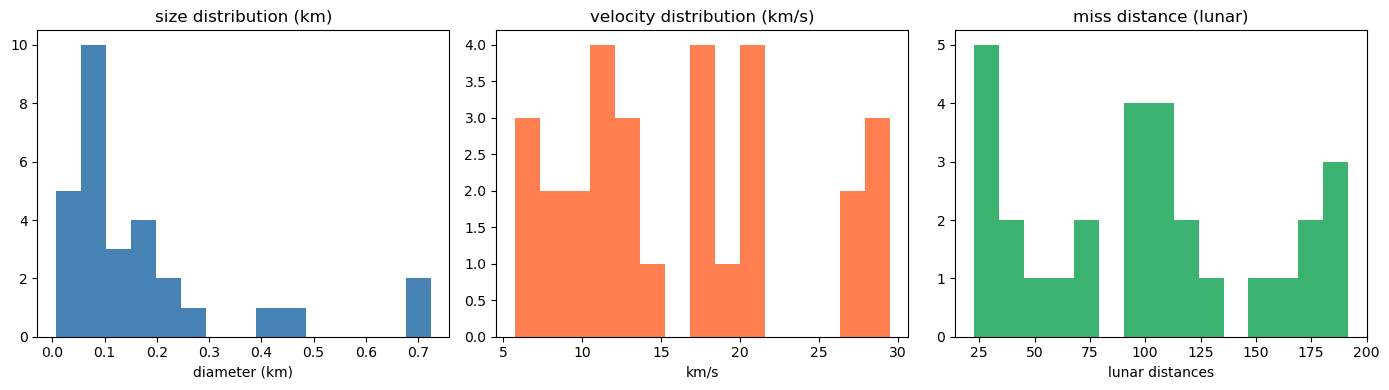

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df["estimated_diameter.kilometers.estimated_diameter_max"], bins=15, color="steelblue")
axes[0].set_title("size distribution (km)")
axes[0].set_xlabel("diameter (km)")

axes[1].hist(df["relative_velocity.kilometers_per_second"], bins=15, color="coral")
axes[1].set_title("velocity distribution (km/s)")
axes[1].set_xlabel("km/s")

axes[2].hist(df["miss_distance.lunar"], bins=15, color="mediumseagreen")
axes[2].set_title("miss distance (lunar)")
axes[2].set_xlabel("lunar distances")

plt.tight_layout()
plt.show()

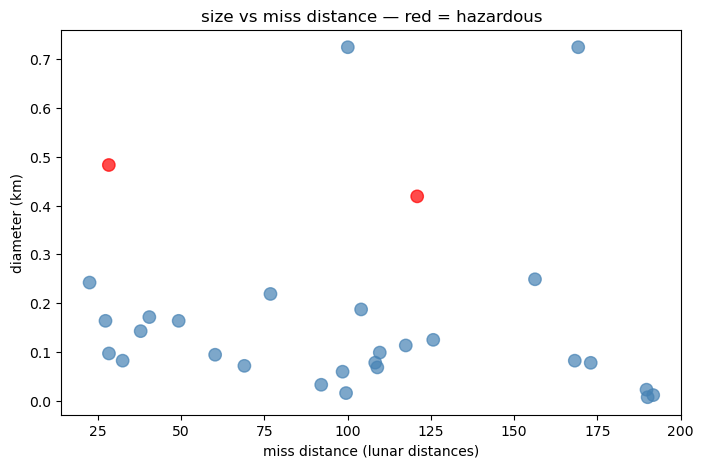

In [52]:
# size vs miss distance colored by hazardous
colors = df["is_potentially_hazardous_asteroid"].map({True: "red", False: "steelblue"})
plt.figure(figsize=(8, 5))
plt.scatter(
    df["miss_distance.lunar"],
    df["estimated_diameter.kilometers.estimated_diameter_max"],
    c=colors, alpha=0.7, s=80
)
plt.xlabel("miss distance (lunar distances)")
plt.ylabel("diameter (km)")
plt.title("size vs miss distance — red = hazardous")
plt.show()

## 9. Summary <a id="9-summary"></a>

### What the API gives us

29 asteroids across 7 days. After flattening and type conversion: 20 columns.

| Category | Fields |
|---|---|
| Identity | id, name, nasa_jpl_url |
| Physical | absolute_magnitude_h, diameter min/max (km) |
| Risk flags | is_potentially_hazardous_asteroid, is_sentry_object |
| Close approach | date, full datetime, epoch timestamp |
| Velocity | km/s, km/h, mph |
| Miss distance | AU, lunar, km, miles |

### Pipeline notes for transform.py

- Velocity and miss distance come as strings — must cast to float
- Meta fields from `json_normalize` lose their types — must cast manually
- `close_approach_date_full` needs datetime conversion
- `miss_distance_au` is perfectly correlated with `miss_distance_lunar` — drop one
- `is_sentry_object` and `is_potentially_hazardous` are independent signals

### What I noticed

- 2 of 29 are hazardous, 2 of 29 are sentry (different objects, I checked)
- Sizes range from 3 meters to 724 meters this week
- Average velocity 16.2 km/s, average miss distance 100 lunar distances
- The hazardous flag clusters toward larger, closer objects
- Full analysis of both flags in `02_neo_enrichipynb`